<a href="https://colab.research.google.com/github/hodyek/lung-colon-cancer-histopathology/blob/main/Notebooks/03_baseline_model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03: Baseline CNN Model

**Student:** Okidi Patrovas Gabriel | 2025/HD07/26018U  
**Institution:** Makerere University, Kampala, Uganda  
**Course:** MSB7216 — Deep Learning for Health Data

## Overview
This notebook trains a small convolutional neural network from scratch on the LC25000 dataset. This model uses no pretrained weights and serves as the performance baseline. Its results define the lower bound that transfer learning models in Notebooks 04 and 05 must exceed. Every design decision here is kept simple intentionally.

## Objectives
1. Load the train/val/test splits saved by Notebook 02.
2. Copy images to local Colab storage for fast GPU training.
3. Define and train a simple CNN from scratch with early stopping.
4. Plot training and validation loss and accuracy curves.
5. Evaluate on the test set and compute all metrics.
6. Plot the confusion matrix and ROC curves.
7. Document the overfitting gap between training and test accuracy.
8. Save the best model weights and results to Drive.

In [3]:
# ── Cell 1: Install and Import ────────────────────────────────────────────────
!pip install torch torchvision --quiet

import os, random, warnings, json, copy, time, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from google.colab import drive

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: GPU not available. Go to Runtime > Change runtime type > T4 GPU')

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB


In [4]:
# ── Cell 2: Mount Drive and Load Splits ───────────────────────────────────────
drive.mount('/content/drive', force_remount=False)

BASE_DIR    = Path('/content/drive/MyDrive/lung-colon-cancer-histopathology')
FIGURES_DIR = BASE_DIR / 'figures'
MODELS_DIR  = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'data' / 'dataset_splits.json', 'r') as f:
    split_data = json.load(f)

train_paths  = split_data['train_paths']
val_paths    = split_data['val_paths']
test_paths   = split_data['test_paths']
train_labels = split_data['train_labels']
val_labels   = split_data['val_labels']
test_labels  = split_data['test_labels']
CLASS_NAMES  = split_data['class_names']

print(f'Train : {len(train_paths):,} | Val : {len(val_paths):,} | Test : {len(test_paths):,}')
print(f'Classes : {CLASS_NAMES}')

Mounted at /content/drive
Train : 3,500 | Val : 750 | Test : 750
Classes : ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [5]:
import shutil
import concurrent.futures
from pathlib import Path

LOCAL_DATA = Path('/content/local_data')

all_paths_combined  = train_paths + val_paths + test_paths
all_labels_combined = train_labels + val_labels + test_labels

# Build list of (source, destination) pairs
copy_tasks = []
for src_path, label in zip(all_paths_combined, all_labels_combined):
    class_name = CLASS_NAMES[label]
    dst_dir    = LOCAL_DATA / class_name
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_path   = dst_dir / Path(src_path).name
    if not dst_path.exists():
        copy_tasks.append((src_path, str(dst_path)))

print(f'Files to copy : {len(copy_tasks)}')

if len(copy_tasks) == 0:
    print('All files already copied.')
else:
    print('Copying using parallel threads...')
    import time
    start = time.time()

    def copy_file(args):
        src, dst = args
        shutil.copy2(src, dst)
        return dst

    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
        futures = list(executor.map(copy_file, copy_tasks))

    elapsed = time.time() - start
    total   = len(list(LOCAL_DATA.rglob('*.jpeg')))
    print(f'Done. {total} files copied in {elapsed:.0f} seconds.')

# Update paths to local storage
def localise_paths(paths, labels):
    return [
        str(LOCAL_DATA / CLASS_NAMES[l] / Path(p).name)
        for p, l in zip(paths, labels)
    ]

train_paths_local = localise_paths(train_paths, train_labels)
val_paths_local   = localise_paths(val_paths,   val_labels)
test_paths_local  = localise_paths(test_paths,  test_labels)

print(f'Train paths updated : {len(train_paths_local)}')
print(f'Val paths updated   : {len(val_paths_local)}')
print(f'Test paths updated  : {len(test_paths_local)}')

Files to copy : 5000
Copying using parallel threads...
Done. 5000 files copied in 226 seconds.
Train paths updated : 3500
Val paths updated   : 750
Test paths updated  : 750


In [6]:
# ── Cell 4: Build DataLoaders ─────────────────────────────────────────────────

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class LC25000Dataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_loader = DataLoader(
    LC25000Dataset(train_paths_local, train_labels, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    LC25000Dataset(val_paths_local, val_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    LC25000Dataset(test_paths_local, test_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'DataLoader reading from : {train_loader.dataset.image_paths[0]}')

Train batches : 110
Val batches   : 24
Test batches  : 24
DataLoader reading from : /content/local_data/lung_n/lungn2467.jpeg


In [7]:
# ── Cell 5: Define Baseline CNN Architecture ──────────────────────────────────

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = BaselineCNN(num_classes=5).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Baseline CNN trainable parameters : {total_params:,}')
print(f'Model is on device                : {next(model.parameters()).device}')

Baseline CNN trainable parameters : 25,785,349
Model is on device                : cuda:0


In [8]:
# ── Cell 6: Training Setup ────────────────────────────────────────────────────

NUM_EPOCHS = 20
PATIENCE   = 5
LR         = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

CHECKPOINT_PATH = str(MODELS_DIR / 'baseline_cnn_best.pth')
RESUME_PATH     = str(MODELS_DIR / 'baseline_cnn_checkpoint.pth')
HISTORY_PATH    = str(MODELS_DIR / 'baseline_cnn_history.json')

print(f'Criterion  : CrossEntropyLoss')
print(f'Optimizer  : Adam (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler  : ReduceLROnPlateau (factor=0.5, patience=3)')
print(f'Max epochs : {NUM_EPOCHS} | Early stop patience : {PATIENCE}')
print(f'Checkpoint : {CHECKPOINT_PATH}')

Criterion  : CrossEntropyLoss
Optimizer  : Adam (lr=0.001, weight_decay=1e-4)
Scheduler  : ReduceLROnPlateau (factor=0.5, patience=3)
Max epochs : 20 | Early stop patience : 5
Checkpoint : /content/drive/MyDrive/lung-colon-cancer-histopathology/models/baseline_cnn_best.pth


In [9]:
# ── Cell 7: Training Loop with Resumable Checkpointing ────────────────────────

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss     = float('inf')
best_weights      = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
START_EPOCH       = 1

# Resume from checkpoint if it exists
if os.path.exists(RESUME_PATH) and os.path.exists(HISTORY_PATH):
    print('Resuming from saved checkpoint...')
    checkpoint    = torch.load(RESUME_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    best_val_loss = checkpoint['best_val_loss']
    START_EPOCH   = checkpoint['epoch'] + 1
    with open(HISTORY_PATH, 'r') as f:
        history = json.load(f)
    print(f'Resumed from epoch {START_EPOCH - 1}.')
    print(f'Best val loss so far : {best_val_loss:.4f}')
else:
    print('Starting training from scratch.')

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    start = time.time()

    # Train
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * images.size(0)
        t_correct += outputs.argmax(1).eq(labels).sum().item()
        t_total   += labels.size(0)

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            v_loss    += loss.item() * images.size(0)
            v_correct += outputs.argmax(1).eq(labels).sum().item()
            v_total   += labels.size(0)

    tr_loss = t_loss / t_total
    tr_acc  = t_correct / t_total
    vl_loss = v_loss / v_total
    vl_acc  = v_correct / v_total

    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - start
    print(f'Epoch {epoch:>3}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'Time: {elapsed:.1f}s')

    # Save best model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CHECKPOINT_PATH)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

    # Save resumable checkpoint after every epoch
    torch.save({
        'epoch'          : epoch,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_loss'  : best_val_loss,
    }, RESUME_PATH)

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history, f)

model.load_state_dict(best_weights)
print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Model saved to : {CHECKPOINT_PATH}')

Resuming from saved checkpoint...
Resumed from epoch 5.
Best val loss so far : 0.6579
Epoch   6/20 | Train Loss: 0.8564 Acc: 0.5569 | Val Loss: 0.6476 Acc: 0.6200 | Time: 21.2s
Epoch   7/20 | Train Loss: 0.8347 Acc: 0.5586 | Val Loss: 0.6413 Acc: 0.6093 | Time: 20.5s
Epoch   8/20 | Train Loss: 0.8122 Acc: 0.5846 | Val Loss: 0.6432 Acc: 0.6120 | Time: 20.7s
Epoch   9/20 | Train Loss: 0.8122 Acc: 0.5746 | Val Loss: 0.5964 Acc: 0.6160 | Time: 20.7s
Epoch  10/20 | Train Loss: 0.8281 Acc: 0.5686 | Val Loss: 0.5850 Acc: 0.6733 | Time: 20.3s
Epoch  11/20 | Train Loss: 0.7789 Acc: 0.5954 | Val Loss: 0.6402 Acc: 0.6213 | Time: 20.3s
Epoch  12/20 | Train Loss: 0.7883 Acc: 0.5803 | Val Loss: 0.6065 Acc: 0.6187 | Time: 20.3s
Epoch  13/20 | Train Loss: 0.7875 Acc: 0.5791 | Val Loss: 0.6336 Acc: 0.6227 | Time: 20.6s
Epoch  14/20 | Train Loss: 0.8081 Acc: 0.5871 | Val Loss: 0.6392 Acc: 0.6440 | Time: 20.8s
Epoch  15/20 | Train Loss: 0.7542 Acc: 0.5877 | Val Loss: 0.5881 Acc: 0.6213 | Time: 20.2s

Ear

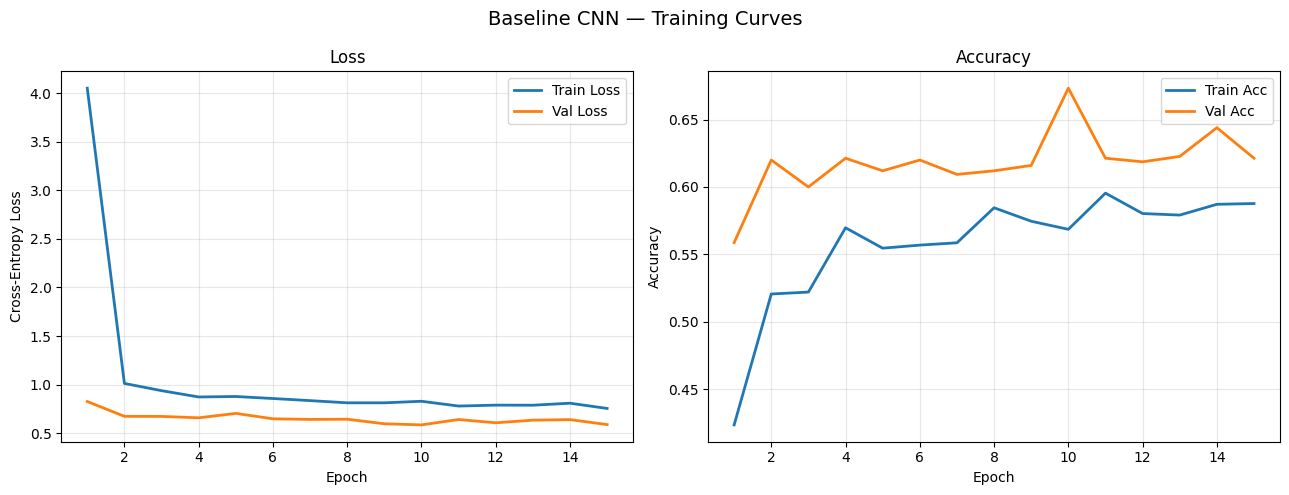

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/03_baseline_training_curves.png


In [10]:
# ── Cell 8: Plot Training Curves ──────────────────────────────────────────────

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline CNN — Training Curves', fontsize=14)

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = FIGURES_DIR / '03_baseline_training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {save_path}')

### Observation — Training Curves

The training curves show how the baseline CNN learns over epochs. A gap between training and validation loss indicates the degree of overfitting. Because this model uses no pretrained weights, it must learn all feature representations from the LC25000 data alone, which typically results in a larger train-val gap compared to transfer learning models. The point at which early stopping triggered gives the effective number of training epochs before the model stopped improving on the validation set.

In [11]:
# ── Cell 9: Test Set Evaluation ───────────────────────────────────────────────

model.eval()
all_labels, all_preds, all_probs = [], [], []
softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = softmax(outputs).cpu().numpy()
        preds   = outputs.argmax(1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

accuracy  = accuracy_score(y_true, y_pred)
macro_f1  = f1_score(y_true, y_pred, average='macro')
y_bin     = label_binarize(y_true, classes=list(range(5)))
macro_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')

cm = confusion_matrix(y_true, y_pred)
per_class = {}
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    per_class[name] = {
        'sensitivity': round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'specificity': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
    }

print('=' * 55)
print('  BASELINE CNN — TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Macro F1  : {macro_f1:.4f}')
print(f'  Macro AUC : {macro_auc:.4f}')
print('=' * 55)
for name, vals in per_class.items():
    print(f'  {name:<15} Sens: {vals["sensitivity"]:.4f}  Spec: {vals["specificity"]:.4f}')
print('=' * 55)

  BASELINE CNN — TEST SET RESULTS
  Accuracy  : 0.6853
  Macro F1  : 0.6617
  Macro AUC : 0.9386
  colon_aca       Sens: 0.7800  Spec: 0.8950
  colon_n         Sens: 0.6000  Spec: 0.9417
  lung_aca        Sens: 0.2067  Spec: 0.9617
  lung_n          Sens: 0.9467  Spec: 0.9967
  lung_scc        Sens: 0.8933  Spec: 0.8117


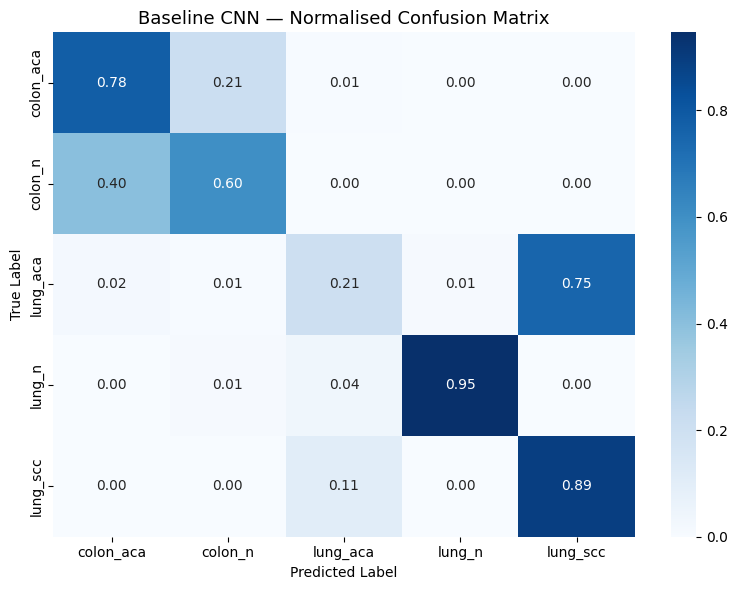

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/03_baseline_confusion_matrix.png


In [12]:
# ── Cell 10: Confusion Matrix ─────────────────────────────────────────────────

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Baseline CNN — Normalised Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
save_path = FIGURES_DIR / '03_baseline_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {save_path}')

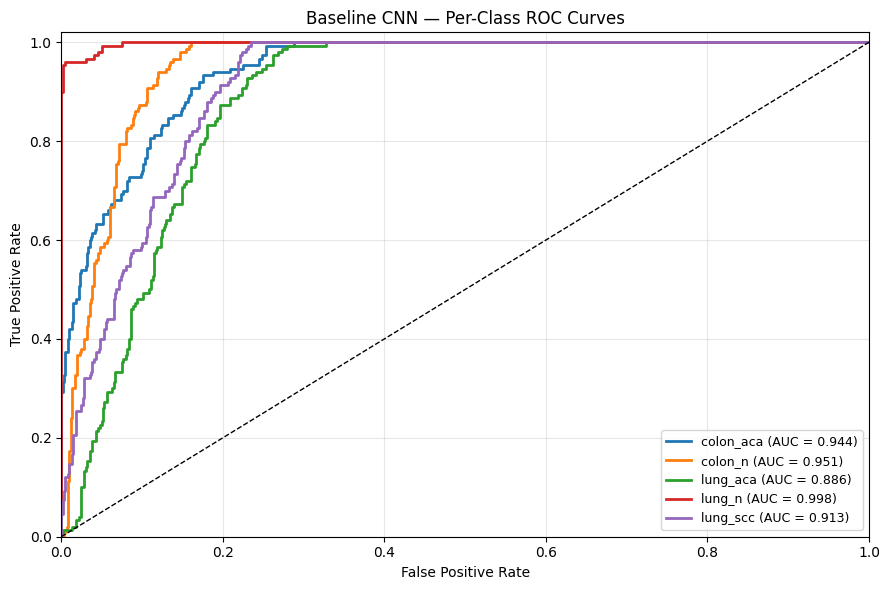

Figure saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures/03_baseline_roc_curves.png


In [13]:
# ── Cell 11: ROC Curves ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10.colors

for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Baseline CNN — Per-Class ROC Curves')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_path = FIGURES_DIR / '03_baseline_roc_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {save_path}')

In [14]:
# ── Cell 12: Overfitting Analysis ─────────────────────────────────────────────

final_train_acc = history['train_acc'][-1]
gap = final_train_acc - accuracy

print('=' * 55)
print('  BASELINE CNN — OVERFITTING ANALYSIS')
print('=' * 55)
print(f'  Final Train Accuracy : {final_train_acc:.4f}')
print(f'  Test Accuracy        : {accuracy:.4f}')
print(f'  Gap                  : {gap:.4f}')
if gap > 0.05:
    print(f'  Status               : WARNING — gap > 5%')
else:
    print(f'  Status               : OK — gap within acceptable range')
print('=' * 55)

  BASELINE CNN — OVERFITTING ANALYSIS
  Final Train Accuracy : 0.5877
  Test Accuracy        : 0.6853
  Gap                  : -0.0976
  Status               : OK — gap within acceptable range


### Observation — Baseline Results

The baseline CNN establishes the lower performance bound for this project. Training from scratch means the model must learn low-level features such as edges and textures before it can learn tissue-level patterns, which requires more epochs and more data than transfer learning approaches. The confusion matrix shows which tissue classes are hardest to separate, and these patterns are expected to improve significantly with pretrained models. The overfitting gap recorded here will be compared directly against the gaps from EfficientNet-B0 and ResNet-50 in the final results table.

In [15]:
# ── Cell 13: Save Results to Drive ────────────────────────────────────────────

results = {
    'model'     : 'Baseline CNN',
    'accuracy'  : round(accuracy, 4),
    'macro_f1'  : round(macro_f1, 4),
    'macro_auc' : round(macro_auc, 4),
    'train_acc' : round(final_train_acc, 4),
    'gap'       : round(gap, 4),
    'per_class' : per_class,
}

results_path = MODELS_DIR / 'baseline_cnn_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f'Results saved to {results_path}')
print(f'Figures saved to {FIGURES_DIR}')
print(f'Model weights saved to {CHECKPOINT_PATH}')

Results saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/models/baseline_cnn_results.json
Figures saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/figures
Model weights saved to /content/drive/MyDrive/lung-colon-cancer-histopathology/models/baseline_cnn_best.pth


In [16]:
# ── Cell 14: Save Notebook to Drive ──────────────────────────────────────────

try:
    shutil.copy('/content/03_baseline_model.ipynb',
                str(BASE_DIR / 'notebooks' / '03_baseline_model.ipynb'))
    print('Notebook saved to Drive.')
except:
    print('Use File > Save a copy in Drive to save this notebook.')

Use File > Save a copy in Drive to save this notebook.
